### Models for Milestone 3

In [20]:
#Librariesfrom sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd
import numpy as np

In [21]:
def categorize_conflict(x, q1, q3):
    if x == 0:
        return 0
    elif x <= q1:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

In [22]:
parquet_path = '../data/output/grid_conflict_climate_2019_23.parquet'

#Drop nas #
df = pd.read_parquet(parquet_path)
df = df.dropna()
new_df = df[df["conflict_count"] > 0]
q1, q2, q3 = new_df['conflict_count'].quantile(0.25), new_df['conflict_count'].quantile(0.50), new_df['conflict_count'].quantile(0.75)

df['target'] = df['conflict_count'].apply(lambda x: categorize_conflict(x, q1, q3))
features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
features = pd.get_dummies(features, columns=['year'], prefix='year')
X = features
y = df['target']

# **Logistic regression finding best model**

### Concerned about class imbalance: rebalancing and getting the best model

In [23]:

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Base model
base_model = LogisticRegression(
    solver='saga',
    penalty='elasticnet',
    max_iter=1000,
    random_state=42
)

# Grid of hyperparameters
param_grid = {
    'C': np.logspace(-3, 1, 5),            # [0.001, 0.01, 0.1, 1, 10]
    'l1_ratio': np.linspace(0, 1, 5)       # [0.0, 0.25, 0.5, 0.75, 1.0]
}

# Grid search with recall_weighted
grid = GridSearchCV(
    base_model,
    param_grid,
    scoring='recall_weighted',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid.fit(X_train_smote, y_train_smote)

# Evaluate
best_model = grid.best_estimator_
y_pred_smote = best_model.predict(X_test_scaled)

print("\n--- Tuned SMOTE + ElasticNet Model ---")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best l1_ratio: {grid.best_params_['l1_ratio']}")
print(f"Best weighted recall (CV): {grid.best_score_:.4f}")

labels = best_model.classes_

# Confusion matrix with labels
conf_matrix = confusion_matrix(y_test, y_pred_smote)
conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

print(f"\nTest Accuracy: {best_model.score(X_test_scaled, y_test):.4f}")
print(f"Test Recall (weighted): {recall_score(y_test, y_pred_smote, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(conf_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/agustin.ep/Library/CloudStorage/OneDrive-TheUniversityofChicago/01 UChicago/04 Spring 2025/02 ML/Cyborg Paul/project-aeyzaguirre-phernandezpedraz-afcamachob/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/agustin.ep/Library/CloudStorage/OneDrive-TheUniversityofChicago/01 UChicago/04 Spring 2025/02 ML/Cyborg Paul/project-aeyzaguirre-phernandezpedraz-afcamachob/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/agustin.ep/Library/CloudStorage/OneDrive-TheUniversityofChicago/01 UChicago/04 Spring 2025/02 ML/Cyborg Paul/project-aeyzaguirre-phernandezpedraz-afcamachob/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn


--- Tuned SMOTE + ElasticNet Model ---
Best C: 10.0
Best l1_ratio: 0.75
Best weighted recall (CV): 0.5215

Test Accuracy: 0.8064
Test Recall (weighted): 0.8064

Confusion Matrix:
      0    1    2    3
0  5302  567  253  129
1    81   78   39   18
2    33   70   48   52
3    15   25   35   58

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      6251
           1       0.11      0.36      0.16       216
           2       0.13      0.24      0.17       203
           3       0.23      0.44      0.30       133

    accuracy                           0.81      6803
   macro avg       0.36      0.47      0.38      6803
weighted avg       0.91      0.81      0.85      6803



#### Plotting the best model of logistic regression

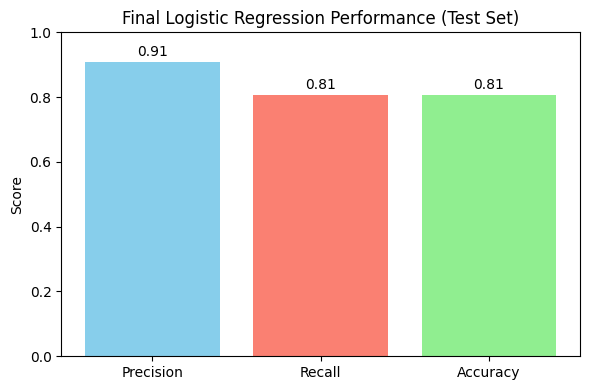

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt

# Re-train using best parameters
final_model = LogisticRegression(
    solver='saga',
    penalty='elasticnet',
    max_iter=1000,
    C=grid.best_params_['C'],
    l1_ratio=grid.best_params_['l1_ratio'],
    random_state=42
)
final_model.fit(X_train_smote, y_train_smote)

# Predict on test set
y_pred_final = final_model.predict(X_test_scaled)

# Compute metrics
precision = precision_score(y_test, y_pred_final, average='weighted')
recall = recall_score(y_test, y_pred_final, average='weighted')
accuracy = accuracy_score(y_test, y_pred_final)

# Plotting
metrics = ['Precision', 'Recall', 'Accuracy']
scores = [precision, recall, accuracy]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, scores, color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1)
plt.title('Final Logistic Regression Performance (Test Set)')
plt.ylabel('Score')

# Add score values on top
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# **SVM Model**

In [24]:
from sklearn.svm import SVC

nlsvm = SVC(kernel="rbf", C=1, gamma=1, class_weight="balanced")
nlsvm.fit(X, y)

SVC(C=1, class_weight='balanced', gamma=1)

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score, precision_score

# Asumiendo que tienes X_test y y_test para evaluación
y_pred_22 = nlsvm.predict(X_test)

labels = nlsvm.classes_

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_22)
conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_22):.4f}")
print(f"Test Precision (weighted): {precision_score(y_test, y_pred_22, average='weighted'):.4f}")
print(f"Test Recall (weighted): {recall_score(y_test, y_pred_22, average='weighted'):.4f}")

print("\nConfusion Matrix:")
print(conf_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_22))



Test Accuracy: 1.0000
Test Precision (weighted): 1.0000
Test Recall (weighted): 1.0000

Confusion Matrix:
      0    1    2    3
0  6251    0    0    0
1     0  216    0    0
2     0    0  203    0
3     0    0    0  133

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6251
           1       1.00      1.00      1.00       216
           2       1.00      1.00      1.00       203
           3       1.00      1.00      1.00       133

    accuracy                           1.00      6803
   macro avg       1.00      1.00      1.00      6803
weighted avg       1.00      1.00      1.00      6803



---
# GRAVEYARD

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [16]:
viz_model = SVC(kernel="rbf", C=1, gamma=1, class_weight="balanced")
viz_model.fit(X_pca, y)

SVC(C=1, class_weight='balanced', gamma=1)

In [17]:
print("Kernel:", viz_model.kernel)
print("C (Regularization parameter):", viz_model.C)
print("Gamma (Kernel coefficient):", viz_model.gamma)
print("Class weights:", viz_model.class_weight)
print("Number of support vectors for each class:", viz_model.n_support_)
print("Support vectors shape:", viz_model.support_vectors_.shape)
print("Indices of support vectors:", viz_model.support_)
print("Dual coefficients of support vector in the decision function:", viz_model.dual_coef_)
print("Intercept(s):", viz_model.intercept_)
print("Number of classes:", len(viz_model.classes_))
print("Classes:", viz_model.classes_)

Kernel: rbf
C (Regularization parameter): 1
Gamma (Kernel coefficient): 1
Class weights: balanced
Number of support vectors for each class: [29626  1073  1004   654]
Support vectors shape: (32357, 2)
Indices of support vectors: [    1     2     3 ... 31638 31639 32062]
Dual coefficients of support vector in the decision function: [[ 0.0677152   0.07279372  0.07398962 ... -1.95571901 -2.08416156
  -1.95572012]
 [ 0.06206093  0.06686361  0.06801694 ... -1.25664654 -1.25664654
  -1.2566703 ]
 [ 0.04066525  0.04352236  0.04444267 ... -1.22215682 -1.22261301
  -1.22212007]]
Intercept(s): [0.9261     0.93227867 0.95588038 0.04133365 0.25672465 0.22224476]
Number of classes: 4
Classes: [0 1 2 3]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_svm_support_vectors(model, X_2d, y):
    plt.figure(figsize=(10, 7))

    # Plot data points by class
    for class_label in np.unique(y):
        plt.scatter(
            X_2d[y == class_label, 0],
            X_2d[y == class_label, 1],
            label=f"Class {class_label}",
            alpha=0.6
        )
    
    # Highlight support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors='none',
        edgecolors='k',
        label='Support Vectors'
    )
    
    plt.title("SVM Support Vectors Visualization")
    plt.xlabel("Feature 1 (or PCA1)")
    plt.ylabel("Feature 2 (or PCA2)")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_num_support_vectors(model):
    counts = model.n_support_
    classes = model.classes_
    
    plt.figure(figsize=(8, 5))
    plt.bar(classes.astype(str), counts, color='skyblue')
    plt.title("Number of Support Vectors per Class")
    plt.xlabel("Class")
    plt.ylabel("Number of Support Vectors")
    plt.grid(axis='y')
    plt.show()

# Call the plotting functions using your trained model and 2D data
plot_svm_support_vectors(viz_model, X_pca, y)
plot_num_support_vectors(viz_model)
